# MediCare Patient Follow-Up Agent
## Task 1 — Data Loading & Exploratory Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("patient_data.csv", parse_dates=["last_visit_date", "next_scheduled_visit"])
print(df.shape)
print("Missing values:", df.isna().sum().sum(), "| Duplicate IDs:", df.patient_id.duplicated().sum())
df.head()

(100, 18)
Missing values: 0 | Duplicate IDs: 0


,patient_id,patient_name,age,gender,diagnosis,current_medication,lab_test,lab_value,lab_unit,last_visit_date,next_scheduled_visit,days_since_last_visit,missed_last_appointment,vitals_bp_systolic,vitals_bp_diastolic,vitals_heart_rate,vitals_spo2,notes
0,P0001,Aarav Sharma,68,Male,Type 2 Diabetes,Metformin 500mg,HbA1c,9.9,%,2024-04-24,2024-06-08,251,No,174,70,95,96,Patient reports good medication adherence.
1,P0002,Priya Patel,29,Male,Heart Failure,Furosemide 40mg,BNP,317.6,pg/mL,2024-01-14,2024-02-28,352,No,174,91,72,97,Patient reports no new symptoms.
2,P0003,Rohan Mehta,45,Male,"Type 2 Diabetes, CKD","Insulin Glargine 10U, Losartan 50mg",HbA1c,11.4,%,2024-08-04,2024-10-03,149,No,132,86,64,91,Medication dose adjusted this visit.
3,P0004,Anjali Singh,34,Female,"COPD, Heart Failure","Tiotropium 18mcg, Furosemide 40mg",FEV1%,33.8,%,2024-01-23,2024-04-22,343,No,153,70,93,94,Patient reports no new symptoms.
4,P0005,Vikram Nair,51,Male,"Hypertension, Heart Failure","Amlodipine 5mg, Furosemide 40mg",BP Systolic,124.9,mmHg,2024-04-26,2024-06-25,249,No,134,71,82,94,Patient education provided on diet and lifestyle.


### Diagnoses
Compound diagnoses are split into a list. `CKD` and `Chronic Kidney Disease` are merged into one name.

In [2]:
df["dx_list"] = df["diagnosis"].str.replace("CKD", "Chronic Kidney Disease").str.split(r"\s*,\s*")
df["n_conditions"] = df["dx_list"].str.len()
print(df["dx_list"].explode().value_counts())
print("\nPatients with 2+ conditions:", (df.n_conditions > 1).sum())

dx_list
Hypertension              25
Heart Failure             23
Type 2 Diabetes           17
Anemia                    14
COPD                      13
Chronic Kidney Disease     9
Hypothyroidism             9
Osteoarthritis             7
Depression                 7
Asthma                     6
Name: count, dtype: int64

Patients with 2+ conditions: 30


### Lab tests
Each patient has one lab test. It matches the **first** diagnosis only.

In [3]:
print(df.groupby(["lab_test", "lab_unit"])["lab_value"].describe()[["count", "min", "50%", "max"]].round(1))
pd.crosstab(df.diagnosis, df.lab_test)

                           count    min    50%     max
lab_test    lab_unit                                  
BNP         pg/mL           12.0   77.2  932.6  1164.0
BP Systolic mmHg            18.0  122.0  146.1   179.5
FEV1%       %               13.0   26.4   47.4    74.8
HbA1c       %               17.0    6.2    9.8    11.5
Hemoglobin  g/dL             6.0    7.4   12.3    12.8
PHQ-9 Score /27              7.0    5.6   21.5    26.6
Pain Score  /10              7.0    2.9    3.6     8.1
Peak Flow   L/min            6.0  222.9  273.2   462.1
TSH         mIU/L            9.0    1.7    7.4    10.1
eGFR        mL/min/1.73m²    5.0   33.5   37.7    52.1


lab_test,BNP,BP Systolic,FEV1%,HbA1c,Hemoglobin,PHQ-9 Score,Pain Score,Peak Flow,TSH,eGFR
diagnosis,,,,,,,,,,
Anemia,0,0,0,0,6,0,0,0,0,0
Asthma,0,0,0,0,0,0,0,6,0,0
COPD,0,0,7,0,0,0,0,0,0,0
"COPD, Heart Failure",0,0,6,0,0,0,0,0,0,0
Chronic Kidney Disease,0,0,0,0,0,0,0,0,0,5
Depression,0,0,0,0,0,7,0,0,0,0
Heart Failure,12,0,0,0,0,0,0,0,0,0
Hypertension,0,5,0,0,0,0,0,0,0,0
"Hypertension, Anemia",0,8,0,0,0,0,0,0,0,0


### Reference ranges
`REF` holds (low, high) normal or target ranges. It is reused by the agent's `check_lab_value` tool in Task 2. HbA1c uses the diabetes target (<7%). Hemoglobin low limit is 13.5 for men and 12.0 for women. Peak flow is a rough adult range, since true normal depends on age, sex and height.

In [4]:
REF = {"HbA1c": (4.0, 7.0), "BNP": (0, 100), "FEV1%": (80, 120), "Hemoglobin": (12.0, 17.5),
       "PHQ-9 Score": (0, 9), "Pain Score": (0, 3), "Peak Flow": (400, 700),
       "TSH": (0.4, 4.0), "eGFR": (60, 200), "BP Systolic": (90, 139)}

def lab_flag(row):
    lo, hi = REF[row.lab_test]
    if row.lab_test == "Hemoglobin" and row.gender == "Male": lo = 13.5
    return "low" if row.lab_value < lo else "high" if row.lab_value > hi else "normal"

df["lab_flag"] = df.apply(lab_flag, axis=1)
pd.crosstab(df.lab_test, df.lab_flag)

lab_flag,high,low,normal
lab_test,,,
BNP,11,0,1
BP Systolic,12,0,6
FEV1%,0,13,0
HbA1c,12,0,5
Hemoglobin,0,5,1
PHQ-9 Score,5,0,2
Pain Score,5,0,2
Peak Flow,0,5,1
TSH,7,0,2


### Which condition does each lab check?
Each lab test measures one condition. Any other condition the patient has is **not checked** by a recent lab.

In [5]:
LAB_FOR = {"HbA1c": "Type 2 Diabetes", "BNP": "Heart Failure", "FEV1%": "COPD",
           "Peak Flow": "Asthma", "eGFR": "Chronic Kidney Disease", "Hemoglobin": "Anemia",
           "TSH": "Hypothyroidism", "PHQ-9 Score": "Depression",
           "Pain Score": "Osteoarthritis", "BP Systolic": "Hypertension"}
df["checked"] = df.lab_test.map(LAB_FOR)
df["not_checked"] = df.apply(lambda r: [d for d in r.dx_list if d != r.checked], axis=1)
gaps = df[df.not_checked.str.len() > 0]
print("Patients with an unchecked condition:", len(gaps))
gaps.explode("not_checked").not_checked.value_counts()

Patients with an unchecked condition: 30


not_checked
Heart Failure             11
Anemia                     8
Hypertension               7
Chronic Kidney Disease     4
Name: count, dtype: int64

### Vitals

In [6]:
df["bp_high"] = (df.vitals_bp_systolic >= 140) | (df.vitals_bp_diastolic >= 90)
df["spo2_low"] = df.vitals_spo2 < 92
df["hr_abnormal"] = (df.vitals_heart_rate < 50) | (df.vitals_heart_rate > 100)
print(df[["bp_high", "spo2_low", "hr_abnormal"]].sum())

bp_high        79
spo2_low       19
hr_abnormal    13
dtype: int64


### Visits
The dataset's "today" is worked out from `last_visit_date + days_since_last_visit`.

In [7]:
as_of = (df.last_visit_date + pd.to_timedelta(df.days_since_last_visit, unit="D")).mode()[0]
df["days_overdue"] = (as_of - df.next_scheduled_visit).dt.days.clip(lower=0)
df["missed"] = df.missed_last_appointment.eq("Yes")
print("Data as of:", as_of.date())
print("Missed last appointment:", df.missed.sum(), "| Next visit already passed:", (df.days_overdue > 0).sum())
print(df.days_overdue.describe().round(0))

Data as of: 2024-12-31
Missed last appointment: 15 | Next visit already passed: 97
count    100.0
mean     157.0
std       90.0
min        0.0
25%       86.0
50%      160.0
75%      233.0
max      330.0
Name: days_overdue, dtype: float64


### Clinical notes
The notes come from a small set of fixed phrases.

In [8]:
df.notes.value_counts()

notes
Referred to specialist for further evaluation.       14
Medication dose adjusted this visit.                 11
Patient education provided on diet and lifestyle.    11
Patient reports dizziness and fatigue.               11
Patient missed doses in last week.                   11
Requires follow-up on lab results.                   10
Patient reports no new symptoms.                      9
Awaiting specialist report.                           9
Patient reports good medication adherence.            7
Lab values improving since last visit.                7
Name: count, dtype: int64

### Risk flags (for EDA only)
`n_flags` just counts warning signs to help us understand the data. It is **not** used to decide actions. The agent makes those decisions in Tasks 4 and 5.

In [9]:
df["lab_abnormal"] = df.lab_flag != "normal"
flags = ["lab_abnormal", "bp_high", "spo2_low", "hr_abnormal", "missed"]
df["n_flags"] = df[flags].sum(axis=1)
print(df.n_flags.value_counts().sort_index())
print(df.groupby("missed")[flags[:-1]].mean().round(2))
df.sort_values(["n_flags", "days_overdue"], ascending=False)[["patient_id", "diagnosis", "lab_test", "lab_value", "days_overdue", "n_flags"]].head(10)

n_flags
0     3
1    19
2    50
3    25
4     3
Name: count, dtype: int64
        lab_abnormal  bp_high  spo2_low  hr_abnormal
missed                                              
False           0.79     0.79      0.20         0.13
True            0.87     0.80      0.13         0.13


,patient_id,diagnosis,lab_test,lab_value,days_overdue,n_flags
98,P0099,"Type 2 Diabetes, Hypertension",HbA1c,9.8,280,4
61,P0062,Asthma,Peak Flow,224.2,226,4
66,P0067,Hypothyroidism,TSH,9.6,86,4
10,P0011,Osteoarthritis,Pain Score,3.8,330,3
49,P0050,"Hypertension, Anemia",BP Systolic,140.6,322,3
65,P0066,"Type 2 Diabetes, CKD",HbA1c,10.1,277,3
54,P0055,"COPD, Heart Failure",FEV1%,47.4,274,3
78,P0079,Heart Failure,BNP,1110.1,266,3
92,P0093,"Type 2 Diabetes, CKD",HbA1c,7.6,248,3
94,P0095,"Hypertension, Anemia",BP Systolic,154.7,243,3


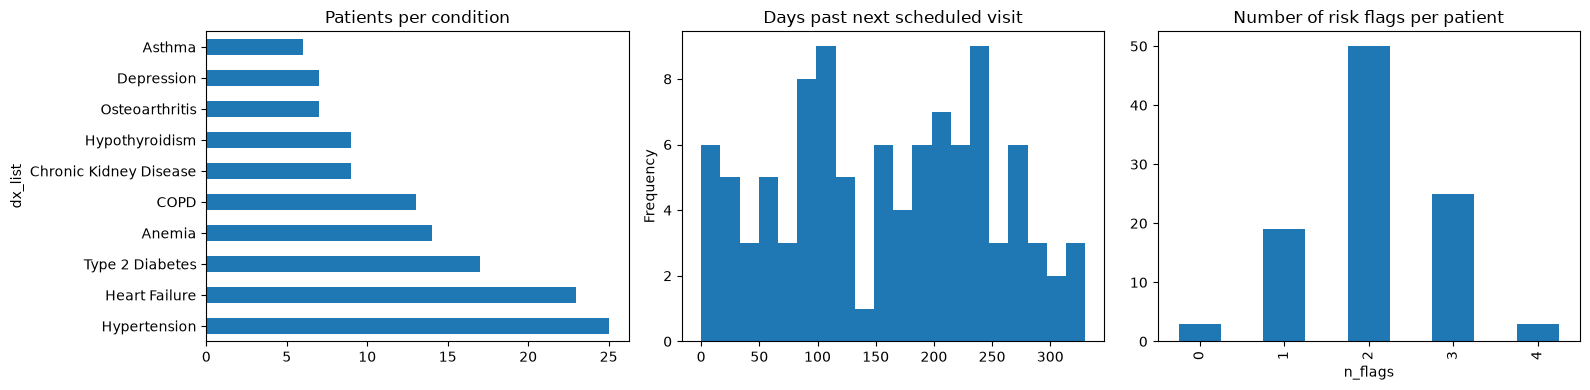

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df.dx_list.explode().value_counts().plot.barh(ax=ax[0], title="Patients per condition")
df.days_overdue.plot.hist(bins=20, ax=ax[1], title="Days past next scheduled visit")
df.n_flags.value_counts().sort_index().plot.bar(ax=ax[2], title="Number of risk flags per patient")
plt.tight_layout(); plt.show()

### Key findings
- **Clean data:** 100 patients, no missing values, no duplicate IDs. Data is as of **2024-12-31**.
- **Wider case mix than the brief:** besides the 5 named conditions, there is also CKD, Hypothyroidism, Depression, Osteoarthritis and Asthma. 30 patients have 2+ conditions.
- **Most labs are abnormal:** 80 of 100 lab values are outside the normal or target range. Examples: BNP is high in 11 of 12 heart-failure patients, and FEV1% is low in all 13 COPD patients.
- **Gaps in monitoring:** each patient has only one lab, which checks just one of their conditions. 30 patients have a condition with no lab: Heart Failure (11, no BNP), Anemia (8, no hemoglobin), Hypertension (7, though BP vitals cover it) and CKD (4, no eGFR). The agent should spot these gaps and suggest the missing tests.
- **Follow-up is broken across the board:** 97 of 100 patients are past their next scheduled visit (median 160 days). 15 missed their last appointment.
- **Missed visits alone are a weak signal:** patients who missed visits have about the same rate of abnormal vitals as those who attended. So risk must combine labs, vitals, comorbidities and notes. This is a good job for an LLM agent.
- **Notes add signal:** 11 patients report dizziness or fatigue, and 11 missed medication doses. These are not visible in the numbers.

## Task 2 — Define Agent Tools
**Design rule:** tools return **facts** (records, ranges, flags). The **LLM decides** risk, priority and actions.
Each tool is a Python function with the `@tool` decorator. LangChain reads the function name, type hints and docstring
to build the tool schema the LLM sees. Only the minimum data goes to the LLM: patient names are left out.

In [11]:
import os, json, uuid
from typing import Literal
from dotenv import load_dotenv
from IPython.display import Markdown, display
from langchain_core.tools import tool
from langgraph.types import interrupt, Command

load_dotenv()  # reads ANTHROPIC_API_KEY from the .env file (key is never written in the notebook)
MODEL = "claude-sonnet-5-5"
FIELDS = ["patient_id", "age", "gender", "diagnosis", "current_medication", "lab_test", "lab_value", "lab_unit",
          "missed_last_appointment", "days_since_last_visit", "days_overdue", "not_checked", "notes"]
VITALS = {"vitals_bp_systolic": (90, 139), "vitals_bp_diastolic": (60, 89),
          "vitals_heart_rate": (50, 100), "vitals_spo2": (92, 100)}
ACTION_PLANS = {}
APPROVAL = {"required": False}  # turned on in the Bonus section for human-in-the-loop review

In [12]:
@tool
def get_patient(patient_id: str) -> dict:
    """Get one patient's full record: diagnosis, meds, latest lab, vitals, visit history,
    conditions with no recent lab (not_checked) and clinical notes."""
    row = df[df.patient_id == patient_id]
    if row.empty: return {"error": f"Patient {patient_id} not found"}
    return json.loads(row[FIELDS + list(VITALS)].iloc[0].to_json())

@tool
def find_patients(condition: str = "", missed_only: bool = False) -> list:
    """List patients with key fields and vitals. Filter by a condition (e.g. 'COPD')
    and/or only patients who missed their last appointment."""
    m = df[df.missed] if missed_only else df
    if condition: m = m[m.dx_list.apply(lambda d: condition.lower() in [x.lower() for x in d])]
    return json.loads(m[FIELDS + list(VITALS)].to_json(orient="records"))

@tool
def check_lab_value(lab_test: str, value: float, gender: str) -> dict:
    """Compare a lab value to its normal/target range and say which condition it measures."""
    if lab_test not in REF: return {"error": f"No reference range for {lab_test}"}
    lo, hi = REF[lab_test]
    if lab_test == "Hemoglobin" and gender == "Male": lo = 13.5
    status = "low" if value < lo else "high" if value > hi else "normal"
    return {"lab_test": lab_test, "value": value, "normal_range": [lo, hi], "status": status, "measures": LAB_FOR.get(lab_test)}

@tool
def check_vitals(patient_id: str) -> dict:
    """Compare a patient's BP, heart rate and SpO2 to normal ranges."""
    row = df[df.patient_id == patient_id]
    if row.empty: return {"error": f"Patient {patient_id} not found"}
    r = row.iloc[0]
    return {v: {"value": int(r[v]), "normal_range": [lo, hi],
                "status": "low" if r[v] < lo else "high" if r[v] > hi else "normal"} for v, (lo, hi) in VITALS.items()}

@tool
def save_action_plan(patient_id: str, priority: Literal["High", "Medium", "Low"], risk_summary: str, actions: list[str]) -> dict:
    """Save the follow-up plan you decided for a patient. Actions must be concrete and include timeframes."""
    plan = {"priority": priority, "risk_summary": risk_summary, "actions": actions}
    if APPROVAL["required"] and interrupt({"patient_id": patient_id, **plan}) != "approve":
        return {"saved": False, "note": "Plan rejected by clinician"}
    ACTION_PLANS[patient_id] = plan
    return {"saved": True, "patient_id": patient_id}

TOOLS = [get_patient, find_patients, check_lab_value, check_vitals, save_action_plan]

Quick test that the tools work (no LLM yet):

In [13]:
print(json.dumps(get_patient.invoke({"patient_id": "P0004"}), indent=1))
print(check_lab_value.invoke({"lab_test": "FEV1%", "value": 33.8, "gender": "Female"}))
print(len(find_patients.invoke({"missed_only": True})), "patients missed their last appointment")

{
 "patient_id": "P0004",
 "age": 34,
 "gender": "Female",
 "diagnosis": "COPD, Heart Failure",
 "current_medication": "Tiotropium 18mcg, Furosemide 40mg",
 "lab_test": "FEV1%",
 "lab_value": 33.8,
 "lab_unit": "%",
 "missed_last_appointment": "No",
 "days_since_last_visit": 343,
 "days_overdue": 253,
 "not_checked": [
  "Heart Failure"
 ],
 "notes": "Patient reports no new symptoms.",
 "vitals_bp_systolic": 153,
 "vitals_bp_diastolic": 70,
 "vitals_heart_rate": 93,
 "vitals_spo2": 94
}
{'lab_test': 'FEV1%', 'value': 33.8, 'normal_range': [80, 120], 'status': 'low', 'measures': 'COPD'}
15 patients missed their last appointment


## Task 3 — Implement the Agentic Loop (LangGraph)
The agent is a **graph**:
- **State:** the list of messages, shared by all nodes.
- **Nodes:** `agent` (the LLM decides what to do) and `tools` (runs the tools the LLM asked for).
- **Edges:** after `agent`, a **conditional edge** goes to `tools` if the LLM asked for a tool, or ends if it gave a final answer. After `tools`, it always goes back to `agent`.
- **Checkpointer:** saves the state after every step, keyed by a `thread_id`. This gives the agent **memory** for follow-up questions.
- **Interrupt:** `save_action_plan` can pause the graph so a clinician approves the plan first (see Bonus).

In [18]:
from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.errors import GraphRecursionError

SYSTEM = """You are a clinical follow-up agent for MediCare Clinic's care coordination team.
Use the tools to look up patient data. Never guess or invent values.
For each patient you review, weigh: lab results, vitals, missed or overdue visits, conditions with no
recent lab (not_checked), medications, and the clinical notes. Then decide a priority (High/Medium/Low)
and concrete follow-up actions with timeframes, and save them with save_action_plan.
Your plans are suggestions for clinician review, not medical orders."""

llm = ChatAnthropic(model=MODEL, max_tokens=4000, max_retries=3).bind_tools(TOOLS)

def agent_node(state: MessagesState):
    return {"messages": [llm.invoke([("system", SYSTEM)] + state["messages"])]}

builder = StateGraph(MessagesState)
builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(TOOLS))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)  # tool call -> "tools", otherwise -> END
builder.add_edge("tools", "agent")
graph = builder.compile(checkpointer=InMemorySaver())

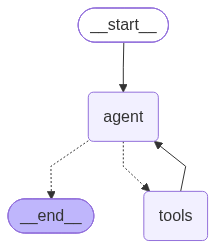

In [19]:
from IPython.display import Image
try: display(Image(graph.get_graph().draw_mermaid_png()))  # draws the graph (needs internet)
except Exception: print(graph.get_graph().draw_mermaid())

In [20]:
def run_agent(task, thread_id=None, max_steps=25):
    """Run the graph and print each tool call. Same thread_id = same conversation (memory)."""
    config = {"configurable": {"thread_id": thread_id or str(uuid.uuid4())}, "recursion_limit": 2 * max_steps}
    inputs = task if isinstance(task, Command) else {"messages": [("user", task)]}
    try:
        for update in graph.stream(inputs, config, stream_mode="updates"):
            for node, out in update.items():
                for m in (out or {}).get("messages", []) if isinstance(out, dict) else []:
                    for tc in getattr(m, "tool_calls", []):
                        print(f"[{node}] {tc['name']}({json.dumps(tc['args'])})")
    except GraphRecursionError:
        return "Stopped: step limit reached."
    state = graph.get_state(config)
    if state.interrupts: return f"⏸ Waiting for clinician approval: {json.dumps(state.interrupts[0].value)}"
    return state.values["messages"][-1].text

## Task 4 — Single Patient Analysis
**Patient P0050** was chosen because the case has several layers:
- Two conditions: Hypertension + Anemia
- The only lab is a BP reading, so **anemia has no recent hemoglobin test**
- SpO2 is low (90%), and the visit is long overdue
- Notes say **dizziness and fatigue**, which are classic anemia symptoms

A good agent should connect these clues on its own. The prompt below does not hint at any of them.

In [21]:
PATIENT = "P0050"
answer = run_agent(f"Review patient {PATIENT}. Check their lab result and vitals, assess their risk, "
                   "and save a follow-up action plan for the care coordination team.")
display(Markdown("### Agent Summary\n" + answer))

[agent] get_patient({"patient_id": "P0050"})
[agent] check_vitals({"patient_id": "P0050"})
[agent] check_lab_value({"lab_test": "BP Systolic", "value": 140.6, "gender": "Male"})
[agent] save_action_plan({"patient_id": "P0050", "priority": "High", "risk_summary": "62M with Hypertension and Anemia. Lab systolic BP 140.6 mmHg (high); today's vitals show systolic 122 (normal) but diastolic 94 (high), so BP is not at goal on amlodipine 5mg. SpO2 90% (low) with reported dizziness and fatigue. Anemia has no recent lab (not_checked), and the last visit was 352 days ago (322 days overdue). Low SpO2 plus symptoms with unmonitored anemia is a concern that needs timely clinician review.", "actions": ["Call patient within 24 hours to assess dizziness, fatigue, shortness of breath, chest pain; escalate to same-day clinician review or urgent or emergency care if symptoms are severe or worsening", "Book clinician appointment within 3 days (not routine scheduling; 322 days overdue) to review low SpO2 9

### Agent Summary
I saved a **High** priority follow-up plan for P0050. It is a suggestion for clinician review.

**Findings**
- **Patient:** 62-year-old male with hypertension and anemia, taking amlodipine 5mg and ferrous sulfate 200mg.
- **Lab:** Systolic BP is 140.6 mmHg, which is high (normal range 90–139).
- **Vitals:**
  - Systolic BP is 122, which is normal.
  - Diastolic BP is 94, which is high.
  - Heart rate is 69, which is normal.
  - SpO2 is 90%, which is low (normal range 92–100).
- **Symptoms:** He reports dizziness and fatigue.
- **Gaps in care:**
  - His anemia has had no recent lab check.
  - His last visit was 352 days ago, so he is 322 days overdue.

**Why High priority:** His blood pressure is not at goal on the current dose. He also has a low SpO2 with dizziness and fatigue, and his anemia hasn't been monitored. Together these need prompt clinician review.

**Planned actions**
1. Call him within 24 hours to check his symptoms. If they are severe or worsening, escalate to same-day clinician review or urgent care.
2. Book a clinician visit within 3 days. This visit should include a repeat SpO2 on room air and an evaluation of the cause of the low reading.
3. Order a CBC, hemoglobin, ferritin and iron studies within 1 week. The clinician should also review how well the ferrous sulfate is working and whether he is taking it.
4. At the visit, check BP again, including orthostatic readings because of the dizziness. The clinician can then decide whether amlodipine needs adjusting.
5. Have him log his BP at home daily for 2 weeks and bring the readings to the visit.
6. Make a coordinator follow-up call at 2 weeks to confirm labs are done and reviewed. After that, set recurring visits every 3 months.

In [22]:
plan = ACTION_PLANS[PATIENT]
print(f"Patient: {PATIENT} | Priority: {plan['priority']}\nRisk: {plan['risk_summary']}\nActions:")
for a in plan["actions"]: print("  -", a)

Patient: P0050 | Priority: High
Risk: 62M with Hypertension and Anemia. Lab systolic BP 140.6 mmHg (high); today's vitals show systolic 122 (normal) but diastolic 94 (high), so BP is not at goal on amlodipine 5mg. SpO2 90% (low) with reported dizziness and fatigue. Anemia has no recent lab (not_checked), and the last visit was 352 days ago (322 days overdue). Low SpO2 plus symptoms with unmonitored anemia is a concern that needs timely clinician review.
Actions:
  - Call patient within 24 hours to assess dizziness, fatigue, shortness of breath, chest pain; escalate to same-day clinician review or urgent or emergency care if symptoms are severe or worsening
  - Book clinician appointment within 3 days (not routine scheduling; 322 days overdue) to review low SpO2 90%, symptoms, and BP
  - Clinician to order CBC, hemoglobin, ferritin and iron studies within 1 week, since anemia has not been checked recently, and review ferrous sulfate response and adherence
  - Repeat SpO2 on room air and

## Task 5 — Missed Appointment Follow-Up
The agent finds every patient who missed their last appointment, reviews each one, saves a plan for each,
and ranks them by urgency. The code only gives the task; the agent decides everything else.

In [23]:
answer5 = run_agent("Find all patients who missed their last appointment. Review each one using their labs, vitals, "
                    "unchecked conditions and notes, and save an action plan for every patient. "
                    "Then give a ranked list from most to least urgent, with a one-line reason for each.")
display(Markdown("### Agent Summary\n" + answer5))

[agent] find_patients({"missed_only": true})
[agent] check_vitals({"patient_id": "P0018"})
[agent] check_vitals({"patient_id": "P0031"})
[agent] check_vitals({"patient_id": "P0036"})
[agent] check_vitals({"patient_id": "P0041"})
[agent] check_vitals({"patient_id": "P0043"})
[agent] check_vitals({"patient_id": "P0058"})
[agent] check_vitals({"patient_id": "P0062"})
[agent] check_vitals({"patient_id": "P0063"})
[agent] check_vitals({"patient_id": "P0066"})
[agent] check_vitals({"patient_id": "P0069"})
[agent] check_vitals({"patient_id": "P0070"})
[agent] check_vitals({"patient_id": "P0076"})
[agent] check_vitals({"patient_id": "P0081"})
[agent] check_vitals({"patient_id": "P0098"})
[agent] check_vitals({"patient_id": "P0099"})
[agent] check_lab_value({"lab_test": "BNP", "value": 952.3, "gender": "Female"})
[agent] check_lab_value({"lab_test": "eGFR", "value": 52.1, "gender": "Female"})
[agent] check_lab_value({"lab_test": "HbA1c", "value": 6.2, "gender": "Female"})
[agent] check_lab_valu

### Agent Summary
I found 15 patients who missed their last appointment and saved an action plan for each. All of them are suggestions for clinician review. One save for P0062 failed the first time because I left out required fields. I resent it with the full plan and it saved.

**Ranked from most to least urgent**

| # | Patient | Priority | Reason |
|---|---|---|---|
| 1 | P0098 | High | Heart failure with the highest BNP (1033.8), missed doses last week, and 117 days overdue. |
| 2 | P0076 | High | Depression with PHQ-9 of 21.6/27 (severe) on sertraline 50mg and SBP 175. Safety status is unknown, so the plan starts with a suicide-risk screen. |
| 3 | P0063 | High | Dizziness and fatigue, with BP 106/110 (an odd pattern worth rechecking), SpO2 92 and lab SBP 172. |
| 4 | P0099 | High | HbA1c 9.8%, SpO2 91 (low), diastolic 101, hypertension not checked, and 280 days overdue (the longest). |
| 5 | P0066 | High | HbA1c 10.1% and BP 158/103 in a 37-year-old, with CKD not checked while on losartan. |
| 6 | P0018 | High | Heart failure with BNP 952 and SBP 160 on furosemide alone. |
| 7 | P0058 | High | Heart failure with BNP 913, SBP 146 and SpO2 93. Notes say values were improving, but the data is old. |
| 8 | P0062 | High | Asthma with peak flow 224 (normal 400–700) and HR 104, on a rescue inhaler only. |
| 9 | P0041 | High | SpO2 90 (low) with no respiratory diagnosis on file. Lab SBP 171 conflicts with the clinic BP of 130/74. |
| 10 | P0043 | High | BP 171/94 on amlodipine, anemia not checked, and 221 days overdue. |
| 11 | P0036 | Medium | BP 181/92 with no antihypertensive listed. HbA1c is in range (6.2%). |
| 12 | P0081 | Medium | TSH 9.8 (high) after a recent levothyroxine dose change, and SBP 157. |
| 13 | P0031 | Medium | CKD with eGFR 52 and diastolic 99, otherwise stable with no new symptoms. |
| 14 | P0070 | Medium | Dizziness and fatigue on ibuprofen, with pain score 3.6/10 and HR 96. |
| 15 | P0069 | Medium | HbA1c 6.9% (in range), but HR 108 is unexplained. |

**Points for the care team**
- **Conflicting BP readings:** P0041 has lab SBP 171 against clinic BP 130/74. P0063 has lab SBP 172 against clinic BP 106/110. Both need a repeat measurement before anyone acts on either number.
- **Conditions with no recent lab:** P0043 (anemia), P0066 (CKD) and P0099 (hypertension). Each plan includes the missing test.
- **Specialist referrals with no recorded outcome:** P0041, P0043, P0066, P0069 and P0099 (still awaiting the report) have referrals or pending reports. P0062 is also awaiting a specialist report. The plans include chasing these.
- **Ranking basis:** I ranked using the lab results, vitals, unchecked conditions, notes and days overdue. Those figures are the only data I had. No symptom reports or other visit information beyond them were available.

In [24]:
pd.set_option("display.max_colwidth", None)
missed = df[df.missed].set_index("patient_id")
summary = pd.DataFrame([{"patient_id": p, "diagnosis": missed.diagnosis[p], **ACTION_PLANS[p]}
                        for p in missed.index if p in ACTION_PLANS])
summary["next_action"] = summary.actions.str[0]
summary = summary.sort_values("priority", key=lambda s: s.map({"High": 0, "Medium": 1, "Low": 2}))
print(f"Plans saved: {len(summary)} of {len(missed)} patients | Missing: {sorted(set(missed.index) - set(summary.patient_id))}")
print(summary.priority.value_counts().to_string())
summary[["patient_id", "diagnosis", "priority", "risk_summary", "next_action"]]

Plans saved: 15 of 15 patients | Missing: []
priority
High      10
Medium     5


,patient_id,diagnosis,priority,risk_summary,next_action
0,P0018,Heart Failure,High,"36-year-old with heart failure and BNP 952.3 pg/mL (markedly high, normal up to 100) on furosemide 40mg only. SBP 160 (high). Missed last appointment, 112 days overdue. Notes show only education given.","Phone call within 48 hours to screen for HF symptoms (dyspnea, edema, weight gain); same-day escalation if symptomatic"
3,P0041,Hypertension,High,"Hypertension on amlodipine 5mg. Last lab SBP 171.4 (high), but current clinic BP 130/74 is normal, so the readings conflict. SpO2 90 (low) with no respiratory diagnosis on file. Missed last appointment, 185 days overdue. Specialist referral outcome unknown.","Call within 48 hours to check for dyspnea, chest pain and cough; send to urgent care if symptomatic"
4,P0043,"Hypertension, Anemia",High,"69-year-old with hypertension (lab SBP 163.8, current 171/94, both high) on amlodipine 5mg. Anemia has no recent lab (not_checked) while on ferrous sulfate. Missed last appointment, 221 days overdue. Specialist referral outcome unknown.",Contact within 48 hours and book a visit within 1 week
5,P0058,Heart Failure,High,"Heart failure with BNP 913.0 pg/mL (about 9x upper limit), although notes say values were improving. SBP 146 (high), SpO2 93 (low-normal), HR 89. Missed last appointment, 111 days overdue. The data is stale, so current status is unknown.",Phone call within 48 hours to check symptoms and SpO2 trend; escalate the same day if dyspnea or edema is present
6,P0062,Asthma,High,"Asthma with peak flow 224.2 L/min (well below the 400-700 range) on salbutamol only. HR 104 (high), SBP 166 (high), SpO2 99. Missed last appointment, 226 days overdue. Specialist report still awaited. Poor control with no controller medication listed.","Call within 48 hours to check for wheeze, night symptoms and rescue-inhaler use, with same-day escalation if he is symptomatic or needs frequent salbutamol"
7,P0063,Hypertension,High,"Hypertension on amlodipine 5mg. Last lab SBP 172.4 (high). Current vitals BP 106/110 (diastolic high, SBP normal, an unusual pattern that may be a measurement error), HR 92, SpO2 92 (borderline). Reports dizziness and fatigue. Missed last appointment, 189 days overdue.","Phone call within 24 hours to assess dizziness, fatigue, chest pain, dyspnea and syncope; send to urgent care if red-flag symptoms are present"
8,P0066,"Type 2 Diabetes, CKD",High,"37-year-old with type 2 diabetes and CKD. HbA1c 10.1% (high) on glargine 10U. CKD has no recent lab (not_checked) while on losartan. BP 158/103 (high). Missed last appointment, 277 days overdue. Specialist referral made and outcome unknown.",Contact within 48 hours and schedule a visit within 1 week
11,P0076,Depression,High,"Depression with PHQ-9 21.6/27 (severe range, normal 0-9) while on sertraline 50mg. Missed last appointment, 109 days overdue. SBP 175 (high). Safety status is unknown.",Clinician or behavioral-health outreach call within 24 hours with a suicide-risk screen and safety assessment; use the crisis pathway if risk is identified
13,P0098,Heart Failure,High,"Heart failure with BNP 1033.8 pg/mL (about 10x upper limit of 100), the highest of the HF patients. Missed doses in the last week. Missed last appointment, 117 days overdue. SBP 140 (mildly high). No fluid-status or symptom data is on file.","Clinician phone call within 24 hours: screen for dyspnea, orthopnea, edema and weight gain, and send to ED/urgent care if symptomatic"
14,P0099,"Type 2 Diabetes, Hypertension",High,"Type 2 diabetes with HbA1c 9.8% (high, target up to 7.0) on metformin only. Hypertension has no recent check (not_checked), diastolic 101 (high). SpO2 91 (low). Missed last appointment, 280 days overdue (the longest overdue). Specialist report is still awaited.","Call within 48 hours to check for respiratory symptoms, and bring the patient in within 3 days to repeat SpO2 and assess the cause of the low reading"


## Bonus 1 — Conversational follow-up (memory)
Both questions use the same `thread_id`, so the checkpointer keeps the conversation.
The second question says "the top one" without naming a patient; the agent remembers who that is.

In [25]:
display(Markdown(run_agent("Which heart failure patients look most at risk? Don't save plans yet, just tell me.", thread_id="chat")))

[agent] find_patients({"condition": "heart failure"})


I ranked the 23 heart failure patients on the data returned and haven't saved any plans. I didn't run `check_lab_value` or `check_vitals`, so the BNP and vitals comments below are my own reading of the numbers.

**Highest risk**
- **P0008** (45 M): BNP is 1100 and SpO2 is 92%. BP is 155/106, he reports dizziness and fatigue, and his follow-up is 159 days overdue.
- **P0079** (37 F): BNP is 1110 and heart rate is 108. She reports dizziness and fatigue, and her follow-up is 266 days overdue.
- **P0047** (42 F): SpO2 is 90%, the lowest in the group, and BP is 174/94. Her heart failure has no recent lab, and she is 243 days overdue.
- **P0098** (56 F): BNP is 1034. She missed her last appointment and missed doses in the past week. She is 117 days overdue.
- **P0023** (40 F): She has the highest BNP at 1164 and a heart rate of 95. She is only 58 days overdue, but she is still awaiting a specialist report.
- **P0014** (43 M): BNP is 1060 and BP is 174/73. She has been overdue for 232 days.

**High risk**
- **P0018 and P0058** (both F): BNP is about 950 and 913. Both missed their last appointment and are about 111 days overdue. P0058's labs are noted as improving.
- **P0085** (43 F): BNP is 909 and she is 285 days overdue. Her vitals are acceptable.
- **P0055** (72 F, COPD): SpO2 is 91% and BP is 159/107. Her heart failure has no recent lab and she is 274 days overdue.
- **P0074** (70 M, COPD): FEV1 is 26.4%, which is very low. BP is 156/100 and he missed doses. His heart failure has no recent lab.
- **P0089** (40 F, COPD): She reports dizziness and fatigue, and her heart rate is 100. FEV1 is 39% and her heart failure has no recent lab.

**Moderate risk**
- **P0004** (COPD): FEV1 is 33.8% and SpO2 is 94%. She is 253 days overdue and her heart failure has no recent lab.
- **P0009**: SpO2 is 92% and BP is 156/88. Her heart failure has no recent lab, but she was seen 66 days ago.
- **P0092**: She reports dizziness and fatigue. Her heart failure has no recent lab and she is 238 days overdue.
- **P0002**: BNP is 318 and BP is 174/91. She is 307 days overdue, the longest in the group.
- **P0051**: BNP is 573 and BP is 158/81.
- **P0084**: She missed doses. BP is 167/99 and her heart failure has no recent lab.

**Lower risk**
- P0035 (BNP 77, dose adjusted), P0017 (BNP 128), P0005, P0060 and P0100. Several of these are still overdue or have no recent heart failure lab.

**Patterns**
- **Heart failure never checked:** For the hypertension and COPD patients, their other condition's lab is what's on file, so BP or FEV1 is standing in for the heart failure lab. These patients may be under-assessed rather than stable.
- **Overdue visits:** Almost everyone is overdue, many by more than 200 days. Overdue status alone doesn't separate patients, so I weighted BNP, SpO2, symptoms and adherence more heavily.
- **Notes:** Several patients' notes say "no new symptoms" despite high BP or long gaps in care, so I wouldn't treat those as reassuring.

I can save plans for the top group, or pull full records on any of these patients first.

In [27]:
display(Markdown(run_agent("For the top one, what should the care team do first?", thread_id="chat")))

This is the same question as your last one, so my answer hasn't changed. I'm still treating P0008 as the top patient.

**First step: a clinician or nurse should phone him within 24 hours.**
- **Why him:** His BNP is 1100.1 pg/mL and his BP is 155/106. His SpO2 is 92%, the bottom of the normal range. He reports dizziness and fatigue, and he is 159 days overdue for follow-up. His only medication on file is furosemide 40 mg.
- **What to ask on the call:** Ask about shortness of breath (including at rest or lying flat), swelling, weight gain, chest pain, fainting and how severe the dizziness is.
- **If he has red-flag symptoms:** Send him to the ED. That means breathlessness at rest, chest pain, fainting or rapidly worsening symptoms.
- **If he doesn't:** Book an in-person visit within 48–72 hours. I'd suggest this timeframe, and a clinician should confirm it.

**At that visit**
- Repeat BNP and a metabolic panel.
- Check orthostatic BP, weight and volume status.
- Have a clinician review his regimen, because furosemide alone may not be enough.
- Confirm whether he has had an echocardiogram or a cardiology referral. The record doesn't say.

The plan is a suggestion for clinician review. I haven't saved anything, as you asked. I can save it as a High priority plan for P0008 or move on to the next patient.

## Bonus 2 — Human-in-the-loop approval (interrupt)
With approval turned on, the graph **pauses** inside `save_action_plan` and waits for a clinician.
Here the approval is scripted so the notebook still runs end to end; a real app would show an Approve button.

In [28]:
APPROVAL["required"] = True
print(run_agent("Review patient P0004 and save a follow-up plan.", thread_id="approval-demo"))

[agent] get_patient({"patient_id": "P0004"})
[agent] check_vitals({"patient_id": "P0004"})
[agent] check_lab_value({"lab_test": "FEV1%", "value": 33.8, "gender": "Female"})
[agent] save_action_plan({"patient_id": "P0004", "priority": "High", "risk_summary": "34F with COPD and heart failure. FEV1% 33.8 (normal 80-120), consistent with severe airflow limitation. Systolic BP 153 is high, and SpO2 94% is at the low end of normal. The visit is 343 days since last (253 days overdue). Heart failure has no recent lab/assessment (not_checked) despite being on furosemide. The note says no new symptoms, but this does not offset the objective findings. Suggestion for clinician review.", "actions": ["Schedule a clinician visit within 1 week (overdue by 253 days); contact the patient by phone within 2 business days to book it and screen for dyspnea, edema, weight gain and orthopnea", "Order heart failure assessment at or before the visit (e.g., BNP/NT-proBNP, renal function and electrolytes on furos

In [29]:
display(Markdown(run_agent(Command(resume="approve"), thread_id="approval-demo")))  # clinician clicks "Approve"
APPROVAL["required"] = False
print("Saved after approval:", "P0004" in ACTION_PLANS)

I saved a **High** priority follow-up plan for P0004. It is a suggestion for clinician review.

**Why High priority**
- **COPD:** FEV1% is 33.8, against a normal range of 80–120. That is a severe reduction, and she is on tiotropium alone.
- **Heart failure:** It has had no recent lab or assessment, even though she takes furosemide.
- **Overdue visit:** Her last visit was 343 days ago, so she is 253 days overdue.
- **Vitals:** Systolic BP is high at 153. Diastolic BP is 70 and heart rate is 93, both normal. SpO2 is 94%, normal but near the low end.
- **Notes:** She reports no new symptoms. I did not treat that as outweighing the objective findings.

**Planned actions**
1. Phone her within 2 business days and book a clinician visit within 1 week. Screen for breathlessness, swelling, weight gain and difficulty breathing when lying flat.
2. Complete a heart failure assessment within 2 weeks. This means BNP/NT-proBNP and kidney function and electrolytes, plus an echocardiogram if she hasn't had a recent one.
3. Recheck BP at the visit and review her heart failure and diuretic regimen. Home BP monitoring for 2 weeks is suggested.
4. Have the clinician review her COPD treatment, including inhaler technique, whether to step up therapy, exacerbation history, and pulmonary rehab or specialist referral. Repeat spirometry within 4 weeks.
5. Recheck SpO2 at the visit. Tell her to seek urgent care for worsening breathlessness, chest pain or rapid weight gain.
6. Coordinator follow-up at 4 weeks to confirm the visit and tests happened, then regular reviews about every 3 months.

Saved after approval: True
